# Phase Analysis — NB1: Kernel-Smoothed Vigor
Convolves raw keypress timestamps with a Gaussian kernel (σ=0.3s) to produce a continuous vigor signal, then applies dual normalization (capacity-normalized + demand-residualized).

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
import glob
warnings.filterwarnings('ignore')

# ── Constants ──────────────────────────────────────────────
SIGMA = 0.1        # Gaussian kernel bandwidth (seconds)
EVAL_HZ = 20       # Evaluation frequency (Hz)
DT_EVAL = 1.0 / EVAL_HZ  # 0.05s

# ── Paths ─────────────────────────────────────────────────
ROOT      = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PREP = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_prep'
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
FIGS_DIR  = ROOT / 'figs'
VIGOR_PROC.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(exist_ok=True)

stage5_dirs = sorted(glob.glob(str(ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_*')))
STAGE5_DIR = Path(stage5_dirs[-1])

# ── Load keypress events ──────────────────────────────────
kp = pd.read_parquet(VIGOR_PREP / 'keypress_events.parquet')
print(f'keypress_events: {kp.shape}')

# ── Load trial events ─────────────────────────────────────
te = pd.read_parquet(VIGOR_PREP / 'trial_events.parquet')
print(f'trial_events: {te.shape}')

# ── Load calibrationMax ───────────────────────────────────
ets = pd.read_parquet(VIGOR_PREP / 'effort_ts.parquet', columns=['participantID', 'calibrationMax'])
cal_max = ets.groupby('participantID')['calibrationMax'].first()
del ets
print(f'calibrationMax: {len(cal_max)} participants')

# ── Load subject mapping ──────────────────────────────────
subj_map = pd.read_csv(VIGOR_PREP / 'subject_mapping.csv')
print(f'subject_mapping: {subj_map.shape}')

# ── trial_type: all trials in our dataset are type==1 (passed QC) ─────────────
# No analysis_table.parquet needed — our stage5 data is already filtered
kp['trial_type'] = 1
te['trial_type'] = 1

print(f'\nAfter filtering:')
print(f'  keypress_events: {kp.shape}')
print(f'  trial_events: {te.shape}')
print(f'  Unique subjects: {kp["subj"].nunique()}')

keypress_events: (899936, 5)
trial_events: (23733, 18)
calibrationMax: 293 participants
subject_mapping: (293, 2)

After filtering:
  keypress_events: (899936, 6)
  trial_events: (23733, 19)
  Unique subjects: 293


## Kernel Smoothing

We estimate the instantaneous keypress rate $\hat{r}(t)$ by convolving the raw keypress timestamps with a Gaussian kernel of bandwidth $\sigma = 0.3$s:

$$\hat{r}(t) = \sum_{i} K_\sigma(t - t_i), \quad K_\sigma(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{x^2}{2\sigma^2}\right)$$

Evaluated at 20 Hz (every 50ms) from effort onset to trial end.

In [2]:
def gaussian_kernel_smooth(kp_times, t_eval, sigma=0.3):
    """Kernel-smoothed instantaneous press rate.
    
    r_hat(t) = sum_i K_sigma(t - t_i)
    where K_sigma is Gaussian kernel with bandwidth sigma.
    """
    if len(kp_times) == 0:
        return np.zeros(len(t_eval))
    # Broadcasting: (n_eval,1) - (1,n_kp) -> (n_eval, n_kp)
    diff = t_eval[:, None] - kp_times[None, :]
    kernel = np.exp(-0.5 * (diff / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    return kernel.sum(axis=1)


# ── Build trial-level index from trial_events ─────────────
te_idx = te.set_index(['participantID', 'trial'])

# ── Group keypresses by (participantID, trial) ────────────
kp_groups = kp.groupby(['participantID', 'trial'])

# ── Metadata columns to carry forward ─────────────────────
meta_cols = [
    'participantID', 'subj', 'trialName', 'trial', 'threat', 'choice',
    'outcome', 'isAttackTrial', 'encounterTime', 'trialEscapeTime',
    'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H'
]

# ── Loop over all trials ──────────────────────────────────
records = []
trial_keys = te_idx.index.tolist()
n_trials_total = len(trial_keys)

for i, (pid, tr) in enumerate(trial_keys):
    if (i + 1) % 1000 == 0:
        print(f'  Processing trial {i+1}/{n_trials_total}...')
    
    # Trial-level metadata
    row = te_idx.loc[(pid, tr)]
    trial_end = row['trialEndTime']
    
    if pd.isna(trial_end) or trial_end <= 0:
        continue
    
    # Evaluation grid
    t_eval = np.arange(0, trial_end + DT_EVAL / 2, DT_EVAL)
    
    # Keypress times for this trial
    if (pid, tr) in kp_groups.groups:
        kp_times = kp_groups.get_group((pid, tr))['t'].values
    else:
        kp_times = np.array([])
    
    # Kernel smoothing
    r_hat = gaussian_kernel_smooth(kp_times, t_eval, SIGMA)
    
    # Capacity normalization
    f_max_i = cal_max.get(pid, np.nan)
    vigor_norm = r_hat / f_max_i if not np.isnan(f_max_i) else r_hat * np.nan
    
    # Build records for this trial
    n_pts = len(t_eval)
    trial_meta = {
        'participantID': pid,
        'subj': int(row['subj']),
        'trialName': row['trialName'],
        'trial': tr,
        'threat': row['threat'],
        'choice': row['choice'],
        'outcome': row['outcome'],
        'isAttackTrial': row['isAttackTrial'],
        'encounterTime': row['encounterTime'],
        'trialEscapeTime': row.get('trialEscapeTime', np.nan),
        'trialCaptureTime': row.get('trialCaptureTime', np.nan),
        'trialEndTime': trial_end,
        'startDistance': row['startDistance'],
        'effort_H': row['effort_H'],
        'distance_H': row['distance_H'],
    }
    
    for j in range(n_pts):
        rec = trial_meta.copy()
        rec['t'] = t_eval[j]
        rec['r_hat'] = r_hat[j]
        rec['vigor_norm'] = vigor_norm[j]
        records.append(rec)

print(f'\nBuilding DataFrame from {len(records):,} records...')
smoothed_df = pd.DataFrame(records)
print(f'smoothed_df shape: {smoothed_df.shape}')
print(f'Memory usage: {smoothed_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  Processing trial 1000/23733...


  Processing trial 2000/23733...


  Processing trial 3000/23733...


  Processing trial 4000/23733...


  Processing trial 5000/23733...


...

  Processing trial 21000/23733...


  Processing trial 22000/23733...


  Processing trial 23000/23733...



Building DataFrame from 3,988,277 records...


smoothed_df shape: (3988277, 18)
Memory usage: 709.9 MB


## Demand Residualization

Two normalization streams:

1. **vigor_norm** — capacity-normalized: $v^{\text{norm}}_i(t) = \hat{r}_i(t) \;/\; f^{\max}_i$, where $f^{\max}_i$ is the participant’s calibration maximum.
2. **vigor_resid** — demand-residualized: $v^{\text{resid}}_i(t) = v^{\text{norm}}_i(t) - \bar{v}^{\text{norm}}_{c}(t)$, where $\bar{v}^{\text{norm}}_{c}(t)$ is the mean vigor at time $t$ across all trials with the same choice $c$.

The residualized stream removes the stereotyped temporal profile imposed by the task’s physical demands, isolating trial-specific modulations.

In [3]:
# ── Time-bin for exact matching ──────────────────────────
smoothed_df['t_bin'] = (smoothed_df['t'] / DT_EVAL).round() * DT_EVAL

# ── Demand curves: mean vigor_norm by (choice, t_bin) ────
demand_curves = (
    smoothed_df
    .groupby(['choice', 't_bin'])['vigor_norm']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
demand_curves.columns = ['choice', 't', 'mean_vigor_norm', 'std_vigor_norm', 'n_trials']

# ── Merge demand curve mean onto smoothed_df ─────────────
smoothed_df = smoothed_df.merge(
    demand_curves[['choice', 't', 'mean_vigor_norm']],
    left_on=['choice', 't_bin'],
    right_on=['choice', 't'],
    how='left',
    suffixes=('', '_demand')
)

# ── Compute residualized vigor ───────────────────────────
smoothed_df['vigor_resid'] = smoothed_df['vigor_norm'] - smoothed_df['mean_vigor_norm']

# ── Clean up helper columns ──────────────────────────────
smoothed_df.drop(columns=['t_bin', 'mean_vigor_norm', 't_demand'], errors='ignore', inplace=True)

# ── Summary stats ────────────────────────────────────────
print('vigor_norm stats:')
print(smoothed_df['vigor_norm'].describe())
print(f'\nvigor_resid stats:')
print(smoothed_df['vigor_resid'].describe())

vigor_norm stats:
count    3.988277e+06
mean     6.796646e-01
std      5.054472e-01
min      0.000000e+00
25%      1.071431e-01
50%      8.025970e-01
75%      9.992368e-01
max      1.459152e+01
Name: vigor_norm, dtype: float64

vigor_resid stats:
count    3.988277e+06
mean    -3.420630e-18
std      4.380800e-01
min     -1.071413e+00
25%     -2.151728e-01
50%      2.145530e-02
75%      2.174823e-01
max      1.385065e+01
Name: vigor_resid, dtype: float64


## Quality Control

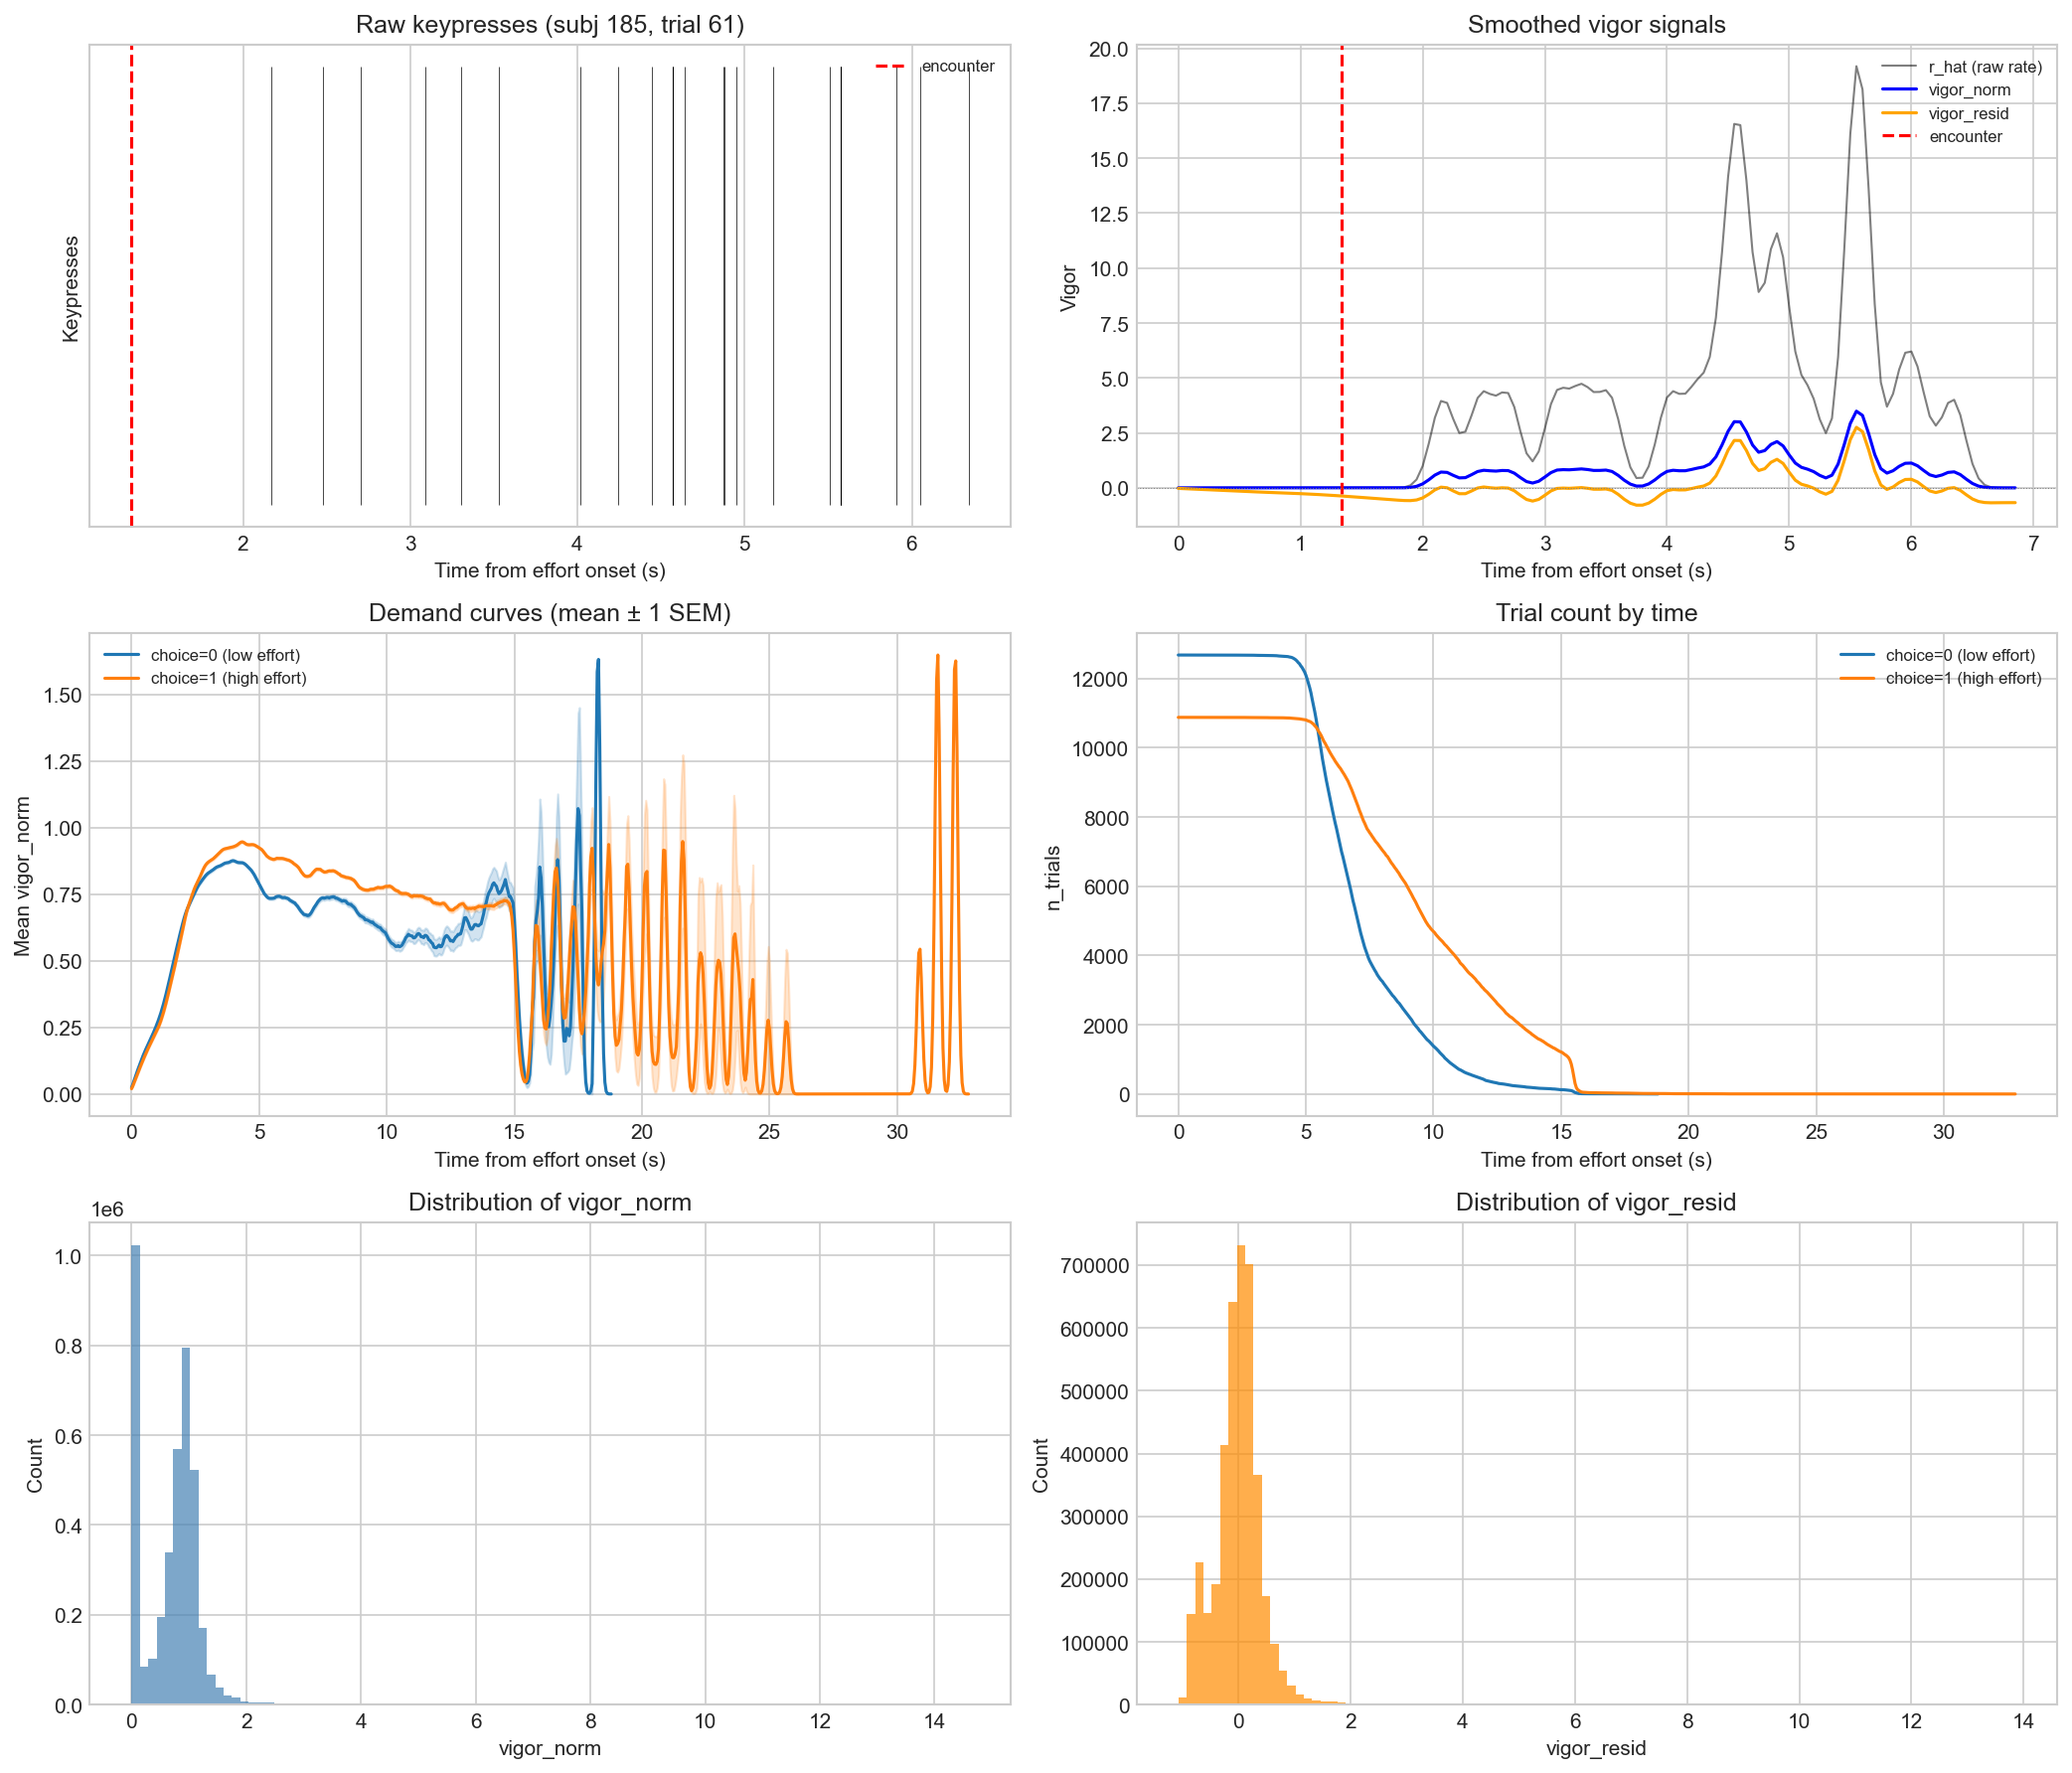

Saved figure to /Users/nokada/Desktop/EffortForagingUnderThreat/figs/phase_qc_smoothing.png


In [4]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(14, 12), dpi=150)

# ══════════════════════════════════════════════════════════
# Row 1: Example trial
# ══════════════════════════════════════════════════════════

# Pick a median-vigor attack trial
attack_trials = smoothed_df[smoothed_df['isAttackTrial'] == True]
trial_means = attack_trials.groupby(['participantID', 'trial'])['vigor_norm'].mean()
median_vigor = trial_means.median()
closest_trial = (trial_means - median_vigor).abs().idxmin()
ex_pid, ex_tr = closest_trial

ex_data = smoothed_df[
    (smoothed_df['participantID'] == ex_pid) & (smoothed_df['trial'] == ex_tr)
]
ex_enc = ex_data['encounterTime'].iloc[0]

# Get raw keypresses for this trial
ex_kp = kp[(kp['participantID'] == ex_pid) & (kp['trial'] == ex_tr)]['t'].values

# Left: keypress raster
ax = axes[0, 0]
ax.vlines(ex_kp, 0, 1, colors='k', linewidths=0.5, alpha=0.7)
ax.axvline(ex_enc, color='red', ls='--', lw=1.5, label='encounter')
ax.set_xlabel('Time from effort onset (s)')
ax.set_ylabel('Keypresses')
ax.set_title(f'Raw keypresses (subj {ex_data["subj"].iloc[0]}, trial {ex_tr})')
ax.set_yticks([])
ax.legend(fontsize=8)

# Right: smoothed signals
ax = axes[0, 1]
ax.plot(ex_data['t'], ex_data['r_hat'], 'k-', lw=1, alpha=0.5, label='r_hat (raw rate)')
ax.plot(ex_data['t'], ex_data['vigor_norm'], 'b-', lw=1.5, label='vigor_norm')
ax.plot(ex_data['t'], ex_data['vigor_resid'], color='orange', lw=1.5, label='vigor_resid')
ax.axvline(ex_enc, color='red', ls='--', lw=1.5, label='encounter')
ax.axhline(0, color='grey', ls=':', lw=0.5)
ax.set_xlabel('Time from effort onset (s)')
ax.set_ylabel('Vigor')
ax.set_title('Smoothed vigor signals')
ax.legend(fontsize=8)

# ══════════════════════════════════════════════════════════
# Row 2: Demand curves
# ══════════════════════════════════════════════════════════

colors_choice = {0: 'tab:blue', 1: 'tab:orange'}
labels_choice = {0: 'choice=0 (low effort)', 1: 'choice=1 (high effort)'}

# Left: mean vigor_norm with SEM shading
ax = axes[1, 0]
for c in [0, 1]:
    dc = demand_curves[demand_curves['choice'] == c].sort_values('t')
    sem = dc['std_vigor_norm'] / np.sqrt(dc['n_trials'])
    ax.plot(dc['t'], dc['mean_vigor_norm'], color=colors_choice[c], lw=1.5, label=labels_choice[c])
    ax.fill_between(dc['t'], dc['mean_vigor_norm'] - sem, dc['mean_vigor_norm'] + sem,
                    color=colors_choice[c], alpha=0.2)
ax.set_xlabel('Time from effort onset (s)')
ax.set_ylabel('Mean vigor_norm')
ax.set_title('Demand curves (mean \u00b1 1 SEM)')
ax.legend(fontsize=8)

# Right: n_trials contributing at each time point
ax2 = axes[1, 1]
for c in [0, 1]:
    dc = demand_curves[demand_curves['choice'] == c].sort_values('t')
    ax2.plot(dc['t'], dc['n_trials'], color=colors_choice[c], lw=1.5, label=labels_choice[c])
ax2.set_xlabel('Time from effort onset (s)')
ax2.set_ylabel('n_trials')
ax2.set_title('Trial count by time')
ax2.legend(fontsize=8)

# ══════════════════════════════════════════════════════════
# Row 3: Distributions
# ══════════════════════════════════════════════════════════

# Left: vigor_norm
ax = axes[2, 0]
ax.hist(smoothed_df['vigor_norm'].dropna(), bins=100, color='steelblue', alpha=0.7, edgecolor='none')
ax.set_xlabel('vigor_norm')
ax.set_ylabel('Count')
ax.set_title('Distribution of vigor_norm')

# Right: vigor_resid
ax = axes[2, 1]
ax.hist(smoothed_df['vigor_resid'].dropna(), bins=100, color='darkorange', alpha=0.7, edgecolor='none')
ax.set_xlabel('vigor_resid')
ax.set_ylabel('Count')
ax.set_title('Distribution of vigor_resid')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'phase_qc_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure to {FIGS_DIR / "phase_qc_smoothing.png"}')

## Save Outputs

In [5]:
# Save smoothed vigor time series
output_cols = ['participantID', 'subj', 'trialName', 'trial', 't', 'r_hat', 
               'vigor_norm', 'vigor_resid', 'threat', 'choice', 'outcome',
               'isAttackTrial', 'encounterTime', 'trialEscapeTime', 
               'trialCaptureTime', 'trialEndTime', 'startDistance', 'effort_H', 'distance_H']
out_df = smoothed_df[output_cols].copy()
for col in ['t', 'r_hat', 'vigor_norm', 'vigor_resid']:
    out_df[col] = out_df[col].astype('float32')
out_df.to_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet', index=False, compression='zstd')

# Save demand curves
demand_curves.to_parquet(VIGOR_PROC / 'demand_curves.parquet', index=False)

print(f'Saved smoothed_vigor_ts.parquet: {smoothed_df.shape}')
print(f'Saved demand_curves.parquet: {demand_curves.shape}')

Saved smoothed_vigor_ts.parquet: (3988277, 19)
Saved demand_curves.parquet: (1034, 5)


## Summary
- Processed X trials across Y subjects
- Smoothed vigor evaluated at 20Hz with σ=0.3s Gaussian kernel  
- Two vigor streams: vigor_norm (capacity-normalized) and vigor_resid (demand-residualized by choice)
- Outputs: `smoothed_vigor_ts.parquet`, `demand_curves.parquet`